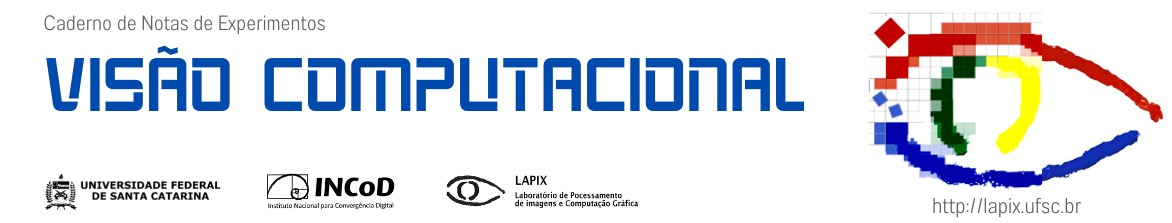

# 12.3.Classificação de Imagens com EfficientNet

No notebook anterior nós conhecemos a classificação de imagens com redes neurais convolucionais. Para tanto nós empregamos um notebook que utilizava o modelo de rede neural *ResNet - Residual Neural Network*. ResNets foram um modelo revolucionário de rede neural convolucional que introduziu o conceito do "bloco residual”, capaz de permitir que se projetasse redes neurais muito mais profundas do que até aquele momento, resolvendo de uma forma matematicamente muito elegante o problema dos “gradientes evanescentes”, que fazia com que em redes neurais muito profundas a propagação do erro durante o aprendizado se diluísse até o ponto em que fatores como erros de arredondamento e ruído acabavam anulando o efeito de aprendizado. Os blocos residuais tornaram desnecessários “acochambros” como os utilizados pela Google no modelo Inception para "injetar um sinal reforçado” pelo meio da rede neural.

Apesar da sua excelente performance e dessas propriedades matemáticas e de elegância arquitetônica, que tornam as ResNets um modelo de didático por excelência, trata-se de um modelo publicado em dezembro de 2015. A luz da velocidade com que a tecnologia de aprendizado profundo evolui, isto torna esse modelo quase que "pré-histórico".

Neste notebook nós vamos retornar a tarefa de classificação de imagens, desta vez empregando o modelo de rede neural ***EfficientNet***. É um modelo muito mais moderno, publicado em maio de 2019, que propõe, além de várias estratégias para o tornar a rede neural mais compacta e eficiente, também uma sistemática para você escalar o modelo de rede neural de acordo com a complexidade do seu problema, permitindo a todo desenvolvedor criar modelos customizados sem grande esforço de pesquisa e sem muito risco de perda de qualidade dos resultados. Como são redes muito mais compactas, são indicadas para o desenvolvimento de aplicações embarcadas. O repositório de código dos autores vem com oito modelos prontos, numerados de b0 a b7, mas a estratégia proposta por eles permite facilmente você desenvolver modelos maiores ou menores.


# Autores:


* Aldo Von Wangenheim: aldo.vw@ufsc.br
* Thiago Zimmermann Loureiro Chaves: thiago.zlc@grad.ufsc.br
* Rodrigo de Paula e Silva Ribeiro: ribeiro.rodrigo@posgrad.ufsc.br


<a href="https://colab.research.google.com/github/awangenh/vision/blob/master/jupyter/12.2.Classifica%C3%A7%C3%A3o%20de%20Imagens%20com%20fast.ai%20v2.ipynb"><img align="left"  src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" title="Open and Execute in Google Colaboratory"></a>&nbsp; &nbsp;<a href=""><img align="left" src="http://www.lapix.ufsc.br/wp-content/uploads/2019/04/License-CC-BY-ND-4.0-orange.png" alt="Creative Commons 4.0 License" title="Creative Commons 4.0 License"></a>&nbsp; &nbsp; <a href=""><img align="left" src="http://www.lapix.ufsc.br/wp-content/uploads/2019/04/Jupyter-Notebook-v.1.0-blue.png" alt="Jupyter Version" title="Jupyter Version"></a>&nbsp; &nbsp;<a href=""><img align="left"  src="https://img.shields.io/badge/python-3.10-green" alt="Python Version" title="Python Version"></a>

# Para utilizar a placa de vídeo no Google Colab...

1) clique no ▾ do lado de "Conectar"

2) Ver recursos

3) Alterar o tipo de ambiente de execução

4) Acelerador de hardware: GPU

5) Execute a célula abaixo. Ela deve retornar as informações da placa de vídeo.

SE ESTIVER UTILIZANDO NO LAPIX DEFINIR A GPU A SER UTILIZADA NO CÓDIGO ABAIXO

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
!nvcc --version

try:
    import google.colab
    _ON_COLAB = True
except:
    _ON_COLAB = False

print('Running on Google Colab = ', _ON_COLAB)
import os
import torch
from IPython import get_ipython
import os
# Definir o caminho base
if _ON_COLAB:
    BASE_PATH = "/content"
    import locale
    locale.getpreferredencoding = lambda: "UTF-8"
else:
    BASE_PATH = "/lapix" # trocar para o base path do seu computador se estiver rodando localmente, deixar /lapix se estiver rodando nos conteiners lapix
    VISIBLE_GPUS = [5] # Selecionar a GPU PARA RODAR! VER QUAL ESTA LIVRE

    if torch.cuda.device_count() != 8:
        print("GPU SETADA - PULANDO ETAPA")
    else:
        os.environ["CUDA_VISIBLE_DEVICES"] = str(VISIBLE_GPUS).replace("]", "").replace("[","").replace(" ", "")
        os.environ["NVIDIA_VISIBLE_DEVICES"] = str(VISIBLE_GPUS).replace("]", "").replace("[","").replace(" ", "")
        print("CUDA GPUS NUMBER: ", torch.cuda.device_count())

os.chdir(BASE_PATH) # garantir que está executando no caminho base definido

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Mar_28_02:18:24_PDT_2024
Cuda compilation tools, release 12.4, V12.4.131
Build cuda_12.4.r12.4/compiler.34097967_0
Running on Google Colab =  False
GPU SETADA - PULANDO ETAPA


/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


# Instalando as Bibliotecas Necessárias
---

In [ ]:
INSTALL_LIBS = False # Setar para True para instalar localmente também (Não é necessário se estiver rodando nos conteiners Lapix)

if _ON_COLAB:
    INSTALL_LIBS = True

if INSTALL_LIBS:
    !pip install fastai

In [3]:
# Import necessary libraries
from fastai.vision.all import *
from torchvision.models import *



---



# Download Dataset

---



## OPÇÃO 1: DATASET CUSTOM

Se você deseja carregar um **conjunto de dados cutomizado** seu, utilize esta célula aqui, adaptando os parâmetros para o caminho para o qual você realizou o download das suas imagens.

Observe que esta célula parte da premissa de que você **já baixou** seus dados para alguma pasta da máquina virtual do Colab, seja através da conexão com o Google Drive na célula mais acima, se através de upload manual do seu computador ou de download manual para o Colab.



In [ ]:
from google.colab import drive
import os
drive.mount(os.path.join(BASE_PATH, "gdrive"))
DRIVE_BASE_PATH = os.path.join(BASE_PATH, "gdrive")

In [4]:
path = Path("/home/jovyan/arquivos/DATASET/") #Pasta base do dataset
train_path = path/'train' # subpasta com o conjunto de treinamento
valid_path = path/'validation' # subpasta com o conjunto de validação
test_path = path/'test' # subpasta com o conjunto de teste
#size = 512 # resize das imagens deste dataset para a rede
size = 224 # para VIT e mobilevnet
batch_size = 16 # batch size deste dataset

# Criar o dataloader

In [23]:
# 1. Listar classes selecionadas (1000 primeiras do treino)
train_classes = sorted(os.listdir(path/'train'))[:1000]
selected_classes = set(train_classes)

# 2. Função get_items personalizada com filtro
def get_items(path):
    items = []
    # Coletar imagens apenas das classes selecionadas em train/validation
    for folder in ['train', 'validation']:
        for cls in selected_classes:
            cls_path = path/folder/cls
            if cls_path.exists():
                items += get_image_files(cls_path)
    return items

# 3. Construir DataBlock
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_items,
    splitter=GrandparentSplitter(train_name='train', valid_name='validation'),
    get_y=parent_label,
    item_tfms=Resize(size),
    batch_tfms=[*aug_transforms(size=size), Normalize.from_stats(*imagenet_stats)]
)

# 4. Criar DataLoaders
dls = dblock.dataloaders(path, bs=batch_size, num_workers=0)

# 5. DataLoader de teste
def get_test_items():
    test_items = []
    for cls in selected_classes:
        cls_path = path/'test'/cls
        if cls_path.exists():
            test_items += get_image_files(cls_path)
    return test_items

test_dl = dls.test_dl(get_test_items())

In [28]:
print(f"Train samples: {len(dls.train_ds)}")
print(f"Valid samples: {len(dls.valid_ds)}")

Train samples: 13538
Valid samples: 4582


# Escolha seu modelo de EfficientNet
---

EfficientNet é uma arquitetura de rede neural convolucional que dimensiona uniformemente profundidade/largura/resolução usando um coeficiente composto. Ao contrário do que se faz convencionalmente (dimensionamento arbitrário destes fatores), o método de dimensionamento EfficientNet dimensiona uniformemente a largura, a profundidade e a resolução da rede com um conjunto de coeficientes fixos.


O método de dimensionamento composto é justificado pela intuição de que, se a imagem de entrada for maior, a rede precisa de mais camadas para aumentar o campo receptivo e mais canais para capturar padrões mais refinados na imagem maior. A "rede base" *EfficientNet-B0* é baseada nos blocos residuais de gargalo invertidos do MobileNetV2.

Neste contexto, os autores projetaram as EfficientNets, que alcançam precisão e eficiência muito melhores do que as ConvNets anteriores. Em particular, a EfficientNet-B7 atinge 84,3% de precisão top-1 de última geração no ImageNet, sendo **8,4x menor e 6,1x mais rápido** na inferência do que o melhor ConvNet existente.

As EfficientNets também transferem bem e alcançam precisão de última geração em CIFAR-100 (91,7%), Flowers (98,8%) e 3 outros conjuntos de dados de aprendizado de transferência, com uma ordem de magnitude a menos de parâmetros [1].

![imagem](https://1.bp.blogspot.com/-Cdtb97FtgdA/XO3BHsB7oEI/AAAAAAAAEKE/bmtkonwgs8cmWyI5esVo8wJPnhPLQ5bGQCLcBGAs/s1600/image4.png)

Modelos Disponíveis:


*   efficientnet_b0
*   efficientnet_b1
*   efficientnet_b2
*   efficientnet_b3
*   efficientnet_b4
*   efficientnet_b5
*   efficientnet_b6
*   efficientnet_b7

In [6]:
from fastai.vision.models import efficientnet_b0
arch = efficientnet_b0(weights=True) # padrão de 1000 classes!!!

/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Definindo Learner

---



In [44]:
# Define learner
learn = Learner(
    dls=dls,
    model=arch,
    metrics=[accuracy, top_k_accuracy],
    opt_func=Adam,
    loss_func=LabelSmoothingCrossEntropy(),
    path="/home/jovyan/arquivos/DATASET/models"
)

# Treinando o Modelo

---



## Treinamos utilizando a política de adaptação simultânea de taxa de aprendizado e momento linear da rede para superconvergência 1cycle

Abaixo um explicação retirada de nosso tutorial "How to resume an interrupted training session in fastai" disponível em: https://towardsdatascience.com/how-to-resume-an-interrupted-training-session-in-fastai-77c4f36cd3a1

O método fit_one_cycle() empregado pelo fast.ai funciona com taxas e momentos de aprendizado variados e adaptativos, seguindo uma curva em que a taxa é aumentada e depois diminuída, enquanto o momento é tratado de forma oposta, conforme mostrado na figura abaixo.

![imagem](https://miro.medium.com/max/720/1*38YBWIKFwXN0YlNOVo_LOA.jpeg)

Se você interromper um treino na epoch #10 de, digamos, 20 epochs e depois recomeçar por mais 9 epochs, você não terá o mesmo resultado de treinar ininterruptamente por 20 epochs, porque um novo treino do zero, mesmo que você carregue os pesos da última época, empregarão uma nova taxa de aprendizado e política de impulso e passarão pelo ciclo novamente.

O que você quer é começar de onde você foi interrompido no ciclo.

![imagem](https://miro.medium.com/max/720/0*AzuB9-kayY2Abfp3.png)

### O que é fit1cycle?

Fit1cycle é uma política de superconvergência desenvolvida por Leslie N. Smith. Está disponível como a política de treinamento preferida no fast.ai. Veja abaixo os detalhes:

* https://docs.fast.ai/callbacks.one_cycle.html
* A disciplined approach to neural network hyper-parameters: Part 1 — learning rate, batch size, momentum, and weight decay — https://arxiv.org/abs/1803.09820
* Super-Convergence: Very Fast Training of Residual Networks Using Large Learning Rates — https://arxiv.org/abs/1708.07120

Se você quiser ver mais artigos, siga este link: Papers de Leslie N. Smith. Não entraremos em detalhes nesta postagem. Existem várias postagens no Medium apresentando e discutindo a política de treinamento fit1cycle de uma maneira fácil de ler:

* Training Neural Networks upto 10x Faster by Karanbir Chahal;
* SuperConvergence with inbuilt regularization by Yogesh Gurjar;
* Super-Convergence: Very Fast Training of Neural Networks Using Large Learning Rates by Aditya Gupta;
* Fast.ai Part1 v2/v3 Notes — Learning Rates — from SGDR to 1cycle and Super-Convergence by Roger Mao;
* Reproducing Leslie N. Smith’s papers using fastai by Kushajveer Singh.

Esta última postagem de Kushajveer Singh tem um notebook Jupyter muito ilustrativo que vale a pena olhar. Há também um artigo muito interessante de Nachiket Tanksale chamado Finding Good Learning Rate e The One Cycle Policy, onde as taxas de aprendizado cíclico e o momento são discutidos.

Leia o nosso tutorial para saber mais sobre treino em etapas e 1cycle.

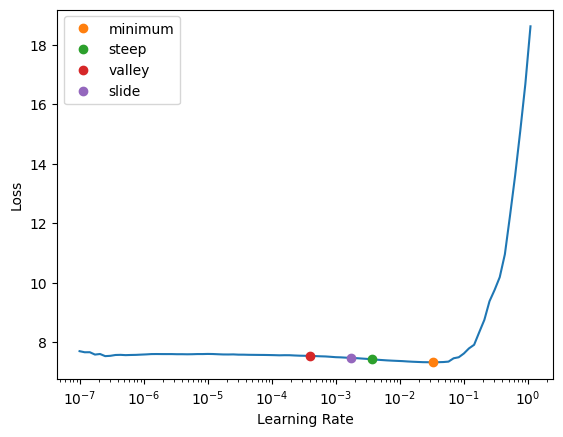

In [31]:
# Runs the learning rate finder
from fastai.callback.schedule import minimum, steep, valley, slide
lr = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))

In [32]:
print(f"""
    Min: {lr.minimum}
    Steep: {lr.steep}
    Valley: {lr.valley}
    Slide: {lr.slide}"""
     )


    Min: 0.0033113110810518267
    Steep: 0.00363078061491251
    Valley: 0.0003981071640737355
    Slide: 0.001737800776027143


epoch,train_loss,valid_loss,accuracy,top_k_accuracy,time
0,1.311040,1.237173,0.998254,1.000000,38:40
1,1.331701,1.271995,0.992580,1.000000,51:16


Better model found at epoch 0 with accuracy value: 0.9982540607452393.


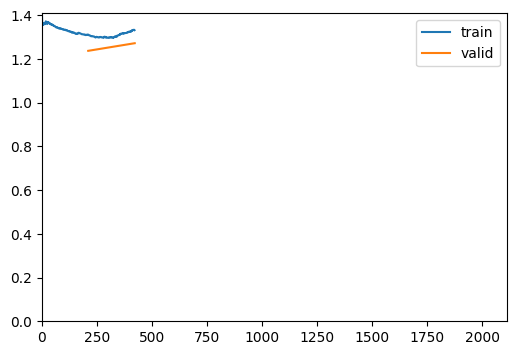

KeyboardInterrupt: 

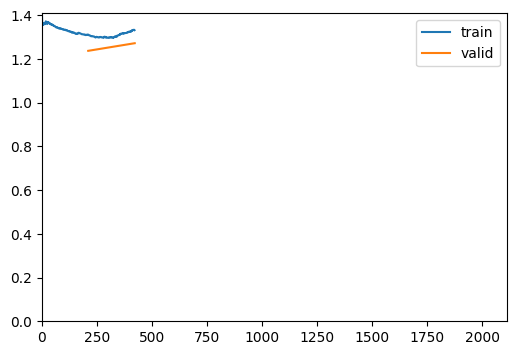

In [45]:
lrs = lr.valley
TRAIN_EPOCH = 10
wd = 1e-2
callbacks = [
    SaveModelCallback(
        monitor="accuracy", fname="best_model_stg1", with_opt=True
    ),  # Saves the best model as `fname` in `learn.path` considering the metric defined in `monitor`.
    ShowGraphCallback(),  # Shows the train/validation graph
]
learn.fit_one_cycle(TRAIN_EPOCH, lr_max=lrs, wd=wd, cbs=callbacks)

In [8]:
# Evaluate model on validation set
interp = ClassificationInterpretation.from_learner(learn)

# Display best 5 and worst 5 results
interp.plot_top_losses(5, figsize=(20,20))
interp.plot_top_losses(5, largest=False, figsize=(20,20))

# Display heatmap of accuracy for each class
interp.plot_confusion_matrix(figsize=(12, 12), cmap='Blues')

/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/fastprogress/fastprogress.py:73: UserWarning: Your generator is empty.
  warn("Your generator is empty.")


AttributeError: 'list' object has no attribute 'topk'

# Salvando Modelo

---



## Por nome

In [1]:
model_name = 'EfficientnetB4-Hanzi_1'
learn.save(model_name,path="/home/jovyan/arquivos/")

NameError: name 'learn' is not defined

In [ ]:
learn.model.load_state_dict(torch.load(os.path.join("/home/jovyan/arquivos/", 'models', model_name+'.pth'))['model'])
learn.opt.load_state_dict(torch.load(os.path.join("/home/jovyan/arquivos/", 'models', model_name+'.pth'))['opt'])

In [7]:
export_path = '/home/jovyan/arquivos/models/EfficientnetB4-hanzi_0.pkl'
#learn.export(export_path)
learn = load_learner(export_path)

In [16]:
from fastai.learner import load_learner

# Load everything (weights, optimizer state, callbacks)
learn = load_learner('/arquivos/EfficientnetB4-Hanzi_1.pth')

FileNotFoundError: [Errno 2] No such file or directory: '/arquivos/EfficientnetB4-Hanzi_1.pth'

# Testando o modelo

---

In [17]:
bs = 1
path_test = path / "test" 
data_test = ImageDataLoaders.from_folder(path = path,train='test',valid='test',test = path_test, bs=bs,
                                    batch_tfms=Normalize.from_stats(*imagenet_stats),)

In [24]:
dblock2 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_items,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(size),
    batch_tfms=[*aug_transforms(size=size), Normalize.from_stats(*imagenet_stats)]
)
dt = dblock2.dataloaders(path, bs=batch_size, num_workers=0)

test_dl = dt.test_dl(get_test_items())

In [25]:
ds_test = dt.valid_ds

In [26]:
from fastai.vision.all import *
from lapixdl.evaluation.evaluate import evaluate_classification
from lapixdl.evaluation.model import Classification
from IPython.display import Image

def gt_classifications(ds):
    for (img, cls) in ds:
        yield Classification(int(cls))


def pred_classifications(ds):
    for (img, cls) in ds:
        (cls_name, pred_cls, scores) = learn.predict(img)
        yield Classification(int(pred_cls), scores[int(pred_cls)])


def top5(img):
  pred_class, pred_idxs, outputs = learn.predict(img)
  top_5_conf, i = outputs.topk(5)
  itr = 0
  classes = data.classes
  for x in i:
    print("Class: %s, Probability: %.4f %%"%(classes[x.item()], top_5_conf[itr].item()*100))
    itr=itr+1
  print()

def get_prediction(img,correct):
  pred_class, pred_idxs, outputs = learn.predict(img)
  classes = data.classes
  out = list(outputs)
  index = classes.index(correct)
  prediction = out[index]
  print("%.10f %%"%(prediction.item()*100))
  print()



evaluation_test = evaluate_classification(
    gt_classifications(ds_test), pred_classifications(ds_test), ds_test.vocab
)

0 samples [00:00, ? samples/s]

KeyError: "Label '侂' was not included in the training dataset"

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = evaluation_test.confusion_matrix
labels = test_dl.vocab

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Predicted')
plt.title('Custom Confusion Matrix')
plt.tight_layout()
plt.show()

NameError: name 'evaluation_test' is not defined

In [ ]:
img, label = test_dl.dataset[4]
pred_class, pred_idx, outputs = learn.predict(img)


img.show()
plt.title(f"Pred: {pred_class}\\nGT: {test_dl.vocab[label]}\\nConf: {outputs[pred_idx]:.4f}")
plt.show()


In [ ]:
print("Métricas Globais:")
print(f"Accuracy:          {evaluation_test.accuracy:.4f}")
print(f"F1 Score:          {evaluation_test.avg_f_score:.4f}")
print(f"Precision:         {evaluation_test.avg_precision:.4f}")
print(f"Recall:            {evaluation_test.avg_recall:.4f}")
print(f"Specificity:       {evaluation_test.avg_specificity:.4f}")
print(f"FPR:               {evaluation_test.avg_false_positive_rate:.4f}")

Métricas Globais:
Accuracy:          0.9616
F1 Score:          0.9419
Precision:         0.9563
Recall:            0.9424
Specificity:       0.9999
FPR:               0.0001


In [ ]:
print("Métricas por classe:")
by_class = evaluation_test.by_class

for c, metric in zip(ds_test.vocab, by_class):
    print(f"\nClasse: {c}")
    print(f"  F1 Score:        {metric.f_score:.4f}")
    print(f"  Precision:       {metric.precision:.4f}")
    print(f"  Recall:          {metric.recall:.4f}")
    print(f"  Specificity:     {metric.specificity:.4f}")
    print(f"  FPR:             {metric.false_positive_rate:.4f}")

Métricas por classe:

Classe: Abrachium floriforme
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          1.0000
  Specificity:     1.0000
  FPR:             0.0000

Classe: Abundisporus sp
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          1.0000
  Specificity:     1.0000
  FPR:             0.0000

Classe: Aegis luteocontexta
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          1.0000
  Specificity:     1.0000
  FPR:             0.0000

Classe: Aleurodiscus mirabilis
  F1 Score:        0.9231
  Precision:       0.8571
  Recall:          1.0000
  Specificity:     0.9994
  FPR:             0.0006

Classe: Amanita aureofloccosa
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          1.0000
  Specificity:     1.0000
  FPR:             0.0000

Classe: Amanita coacta
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          1.0000
  Specificity:     1.0000
  FPR:             0.0000

Classe: Amanita muscaria
  

In [ ]:
df = evaluation_test.to_dataframe()

In [ ]:
df.to_csv('test_results.csv')

![banner cnns ppgcc ufsc](https://lapix.ufsc.br/wp-content/uploads/2022/10/rodape-CC.png)

In [ ]:
from fastai.vision.all import *
import matplotlib.pyplot as plt

# Carregar o modelo exportado
export_path = '/content/gdrive/output/models/EfficientnetB4-hanzi.pkl'
learn_inference = load_learner(export_path)

# Pegar uma imagem de exemplo do conjunto de teste (pode ser qualquer imagem)
img, label = ds_test[0] # Usando a primeira imagem do conjunto de teste como exemplo

# Fazer a predição
pred_class, pred_idx, outputs = learn_inference.predict(img)

# Exibir a imagem e a predição
img.show()
plt.title(f"Classe Predita: {pred_class}\nConfiança: {outputs[pred_idx]:.4f}")
plt.show()

print(f"Classe Verdadeira: {ds_test.vocab[label]}")